<div style='text-align:center'>
    <h1>Variations: Single star evolution</h1>
    <p>How does removing binary interactions after the MW BHs?</p>
</div>

In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [74]:
reload(helpers)
parts = [0, 1, 2, 3, 4, 5, 6, 8, 9, 10]
singles = helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/singles", parts, label="Singles", colour="darkgrey")
binaries = helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5", parts, label="Binaries", colour="#96B73B")

Loading distributed population Binaries from 10 parts
   loaded part 1/10 of Binaries with 179379 binaries
   loaded part 2/10 of Binaries with 178696 binaries
   loaded part 3/10 of Binaries with 177856 binaries
   loaded part 4/10 of Binaries with 178671 binaries
   loaded part 5/10 of Binaries with 179015 binaries
   loaded part 6/10 of Binaries with 179239 binaries
   loaded part 7/10 of Binaries with 178912 binaries
   loaded part 8/10 of Binaries with 179055 binaries
   loaded part 9/10 of Binaries with 179140 binaries
   loaded part 10/10 of Binaries with 178805 binaries


# Totals

In [75]:
scale_up = 6e10 / binaries.mass_binaries
scale_up

np.float64(330.38558290728986)

Singles
  Total: 979437, NSs: 721909, BHs: 257528
Binaries
  Total: 995652, NSs: 717975, BHs: 277677


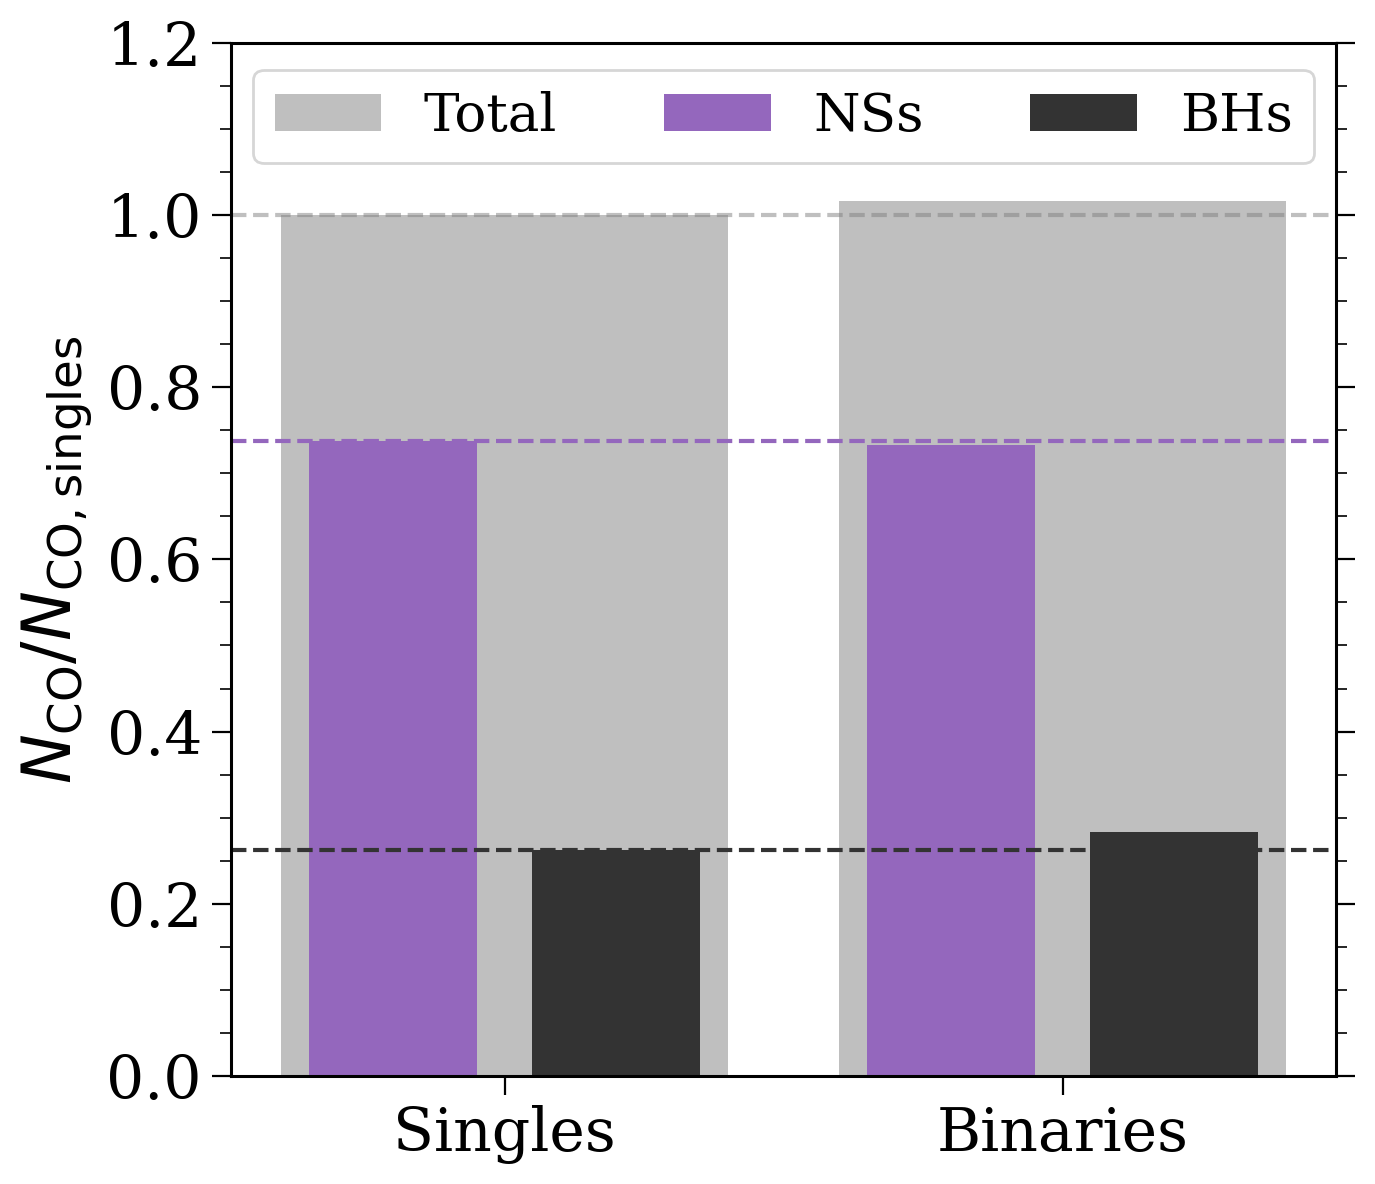

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

total_single_cos = None

for i, pop in enumerate([singles, binaries]):
    n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
    n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")

    if total_single_cos is None and pop.label == "Singles":
        total_single_cos = n_ns + n_bh

    ax.bar(i, (n_ns + n_bh) / total_single_cos, label="Total" if i == 0 else None, color="grey", alpha=0.5)
    ax.bar(i - 0.2, n_ns / total_single_cos, width=0.3, label="NSs" if i == 0 else None, color="tab:purple")
    ax.bar(i + 0.2, n_bh / total_single_cos, width=0.3, label="BHs" if i == 0 else None, color="#333")

    if i == 0:
        ax.axhline((n_ns + n_bh) / total_single_cos, color="grey", alpha=0.5, ls='--')
        ax.axhline(n_ns / total_single_cos, color="tab:purple", ls='--')
        ax.axhline(n_bh / total_single_cos, color="#333", ls='--')

pops = [singles, binaries]
ax.set_xticks(range(len(pops)), [pop.label for pop in pops])
ax.set_ylabel(r"$N_{\rm CO} / N_{\rm CO, singles}$")
ax.legend(ncol=3, loc='upper center', fontsize=0.8*fs)

ax.set(
    ylim=(0, 1.2),
)

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# show yticks on both sides
ax.yaxis.set_ticks_position('both')

plt.tight_layout()
plt.show()

## Takeaways

Binaries are produce slightly more compact objects?

- Mergers increasing the amount that can reach core-collapse?

Binaries don't have a strong effect on the NSs, but slightly increase the BH total.

- Hypothesis: Stars can now become NSs, some NSs can now become BHs, BHs only go up


## It's mergers right?

Mergers can both increase and decrease the total number of COs formed from a given total stellar mass since:

1. A merger of two stars that could both have become COs decreases your CO count by 1
2. A merger of two low mass stars that couldn't become COs without merging increases your count by 1

Arguably from the IMF, the latter should be more common and so binaries should make many more COs

In [6]:
stellar_merger_nums = binaries.bpp[(
    (
        (binaries.bpp['kstar_1'] == 15) & (binaries.bpp["kstar_2"] < 13)
    ) | (
        (binaries.bpp['kstar_2'] == 15) & (binaries.bpp["kstar_1"] < 13)
    )
)].drop_duplicates(subset="bin_num", keep="first")["bin_num"]

In [7]:
merger_inits = binaries.initC.loc[stellar_merger_nums]

In [8]:
bh_bin_nums = binaries.final_bpp["bin_num"][(binaries.final_bpp["kstar_1"] == 14) | (binaries.final_bpp["kstar_2"] == 14)].values

In [9]:
merger_bhs = binaries.final_bpp.loc[merger_inits["bin_num"]][["kstar_1", "kstar_2"]].min(axis=1) == 14

In [10]:
min_exploding_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_explode_crit.h5", key="min_exploding_mass")
min_exploding_mass = interp1d(min_exploding_mass_df["metallicity"], min_exploding_mass_df["mass_1"])

min_bh_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass")
min_bh_mass = interp1d(min_bh_mass_df["metallicity"], min_bh_mass_df["mass_1"])

In [11]:
LIM = 7.5
high_mass_mergers = (merger_inits["mass_1"] >= LIM) & (merger_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_inits["mass_1"] < LIM) & (merger_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits)}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits):.2%})")

Total mergers: 678845
  High mass mergers: 206628 (30.44%)
  Low mass mergers: 238813 (35.18%)


In [94]:
LIM = min_exploding_mass(merger_inits["metallicity"].values)
high_mass_mergers = (merger_inits["mass_1"] >= LIM) & (merger_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_inits["mass_1"] < LIM) & (merger_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits)}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits):.2%})")

Total mergers: 678845
  High mass mergers: 214153 (31.55%)
  Low mass mergers: 224057 (33.01%)


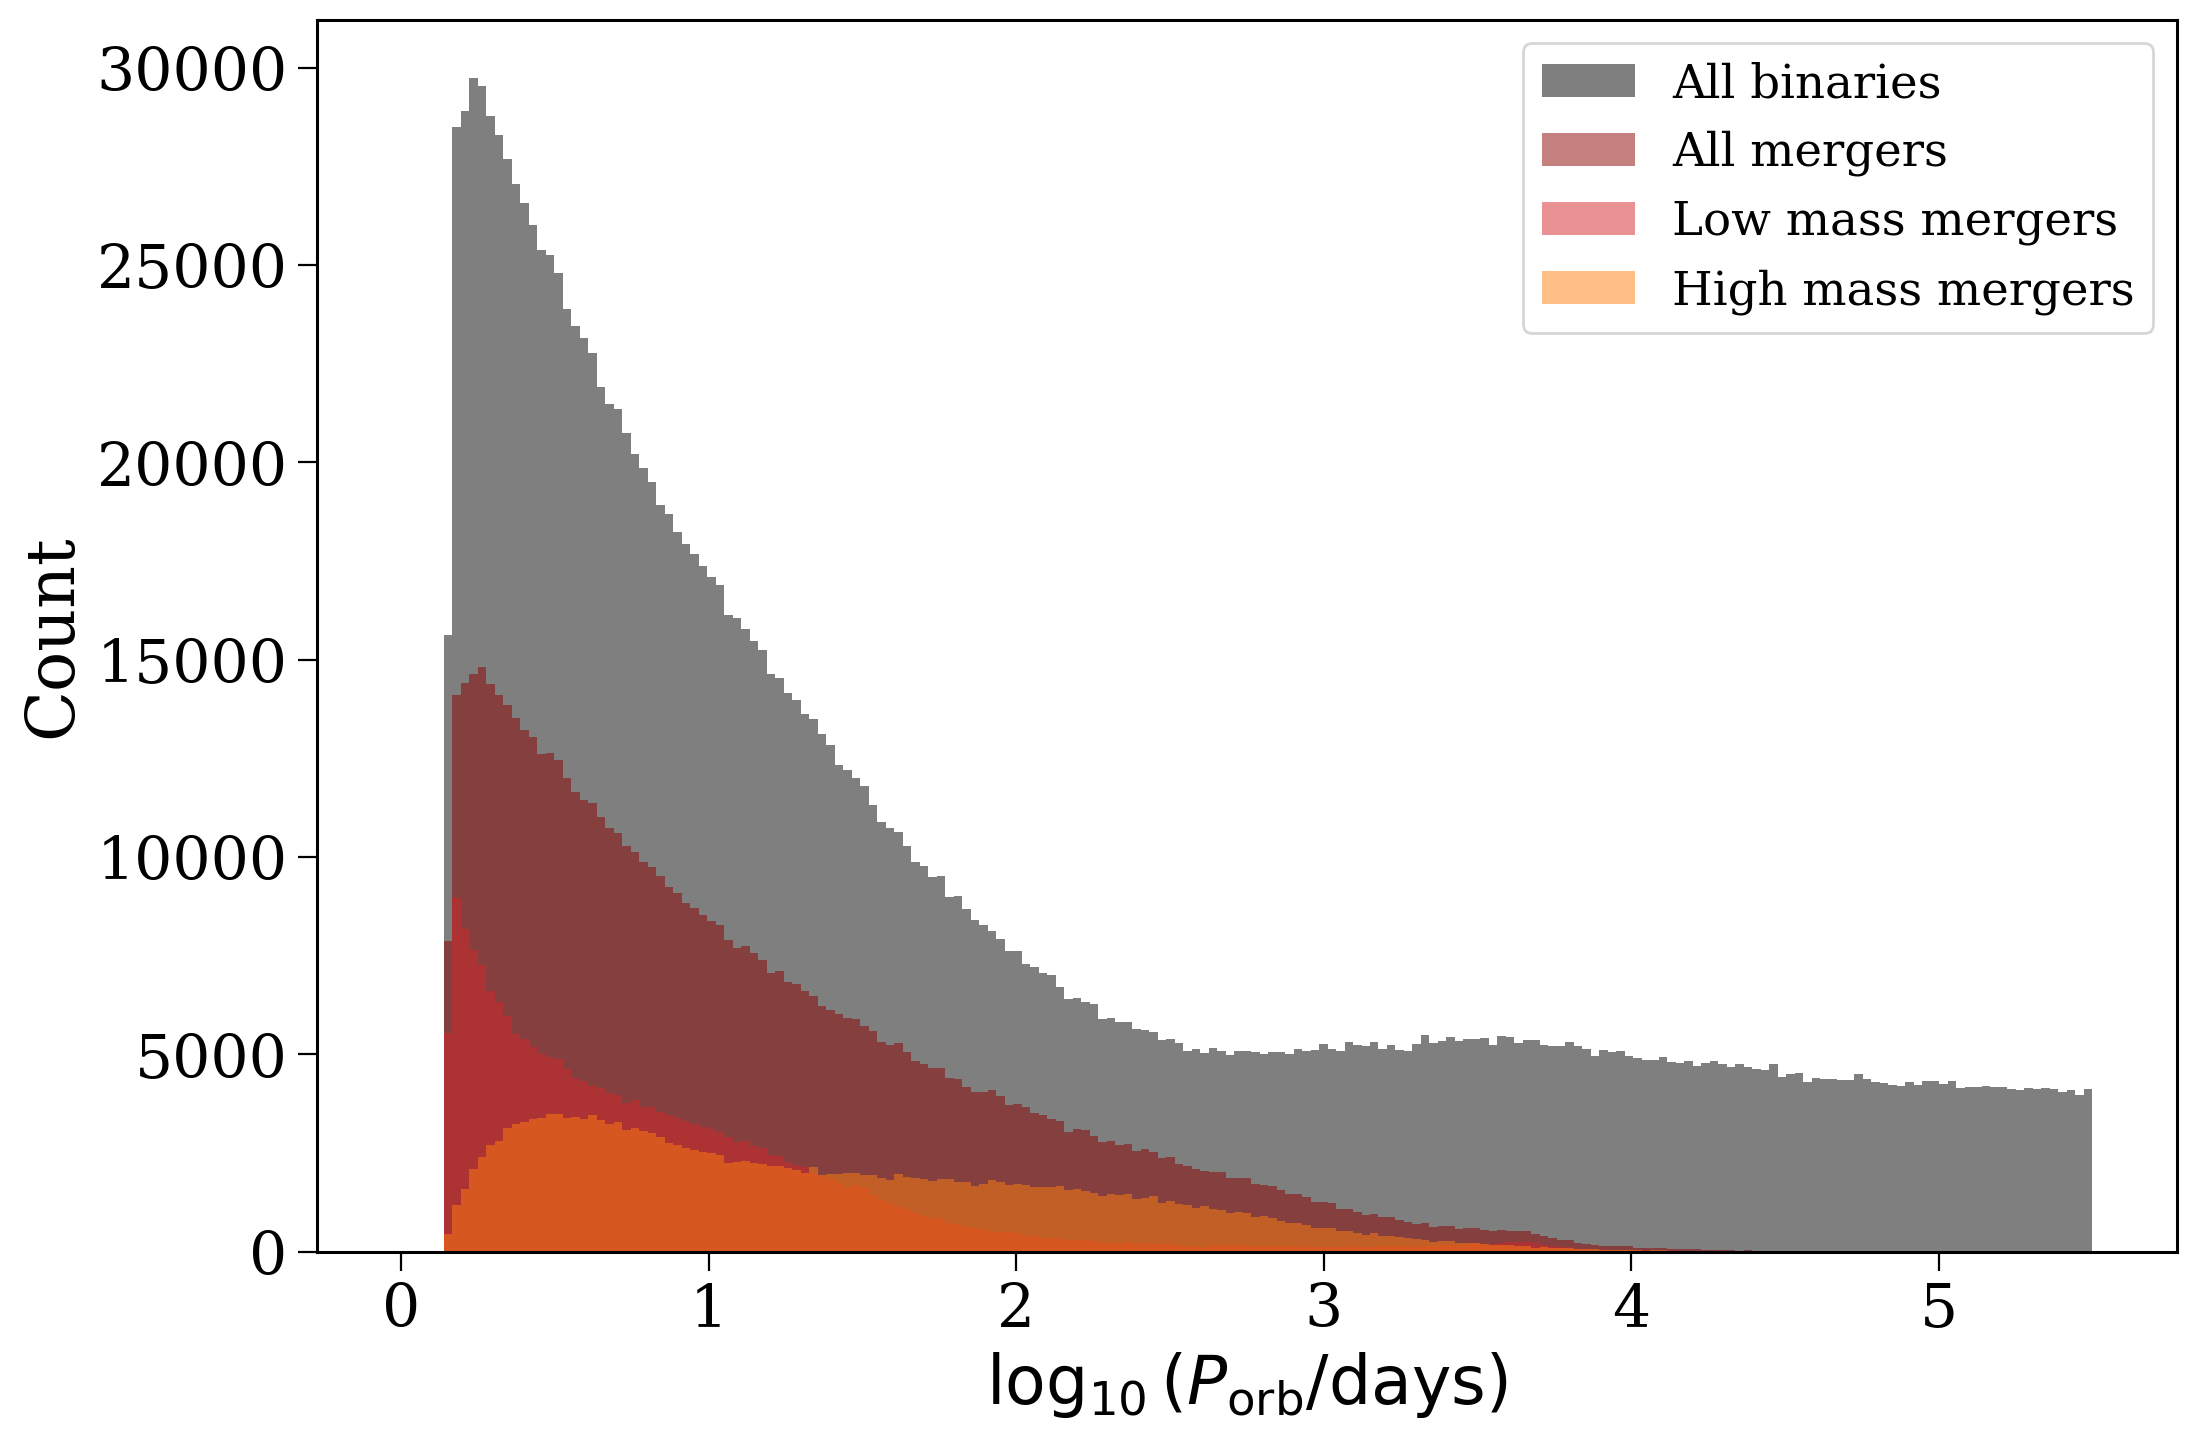

In [96]:
fig, ax = plt.subplots()

ax.hist(np.log10(binaries.initC["porb"]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="All binaries", color="black")
ax.hist(np.log10(merger_inits["porb"]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="All mergers", color="darkred")
ax.hist(np.log10(merger_inits["porb"][low_mass_mergers]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="Low mass mergers", color="tab:red")
ax.hist(np.log10(merger_inits["porb"][high_mass_mergers]), bins=np.linspace(0, 5.5, 200), alpha=0.5, label="High mass mergers", color="tab:orange")

ax.set(
    xlabel=r"$\log_{10}(P_{\rm orb} / \mathrm{days})$",
    ylabel="Count",
)
ax.legend()
plt.show()

In [97]:
LIM = min_bh_mass(merger_inits[merger_bhs]["metallicity"].values)
high_mass_mergers = (merger_inits[merger_bhs]["mass_1"] >= LIM) & (merger_inits[merger_bhs]["mass_2"] >= LIM)
low_mass_mergers = (merger_inits[merger_bhs]["mass_1"] < LIM) & (merger_inits[merger_bhs]["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits[merger_bhs])}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / n_bh:.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / n_bh:.2%})")

Total mergers: 190221
  High mass mergers: 50356 (18.13%)
  Low mass mergers: 72382 (26.07%)


# Mass distributions

In [58]:
masses = {}
for pop in pops:
    masses[pop.label] = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    masses[pop.label]["CO"] = np.concatenate((masses[pop.label]["NS"], masses[pop.label]["BH"]))

In [59]:
f'{masses["Binaries"]["BH"].sum() / masses["Singles"]["BH"].sum():1.1f}x more mass in BHs in binaries vs singles'

'1.2x more mass in BHs in binaries vs singles'

In [60]:
f'{masses["Binaries"]["BH"].mean() / masses["Singles"]["BH"].mean():1.1f}x higher average mass in binaries vs singles'

'1.1x higher average mass in binaries vs singles'

# Kinematics

In [78]:
kinematics = helpers.get_kinematics([singles, binaries])

stars = cogsworth.sfh.SandersBinney2015(
    size=500000,
    **{
        "potential": binaries.galactic_potential,
        "time_bins": 5,
        "verbose": True
    }
)

Pre-computing lookback time, guiding radius and frequency interpolations
Initiating sampling procedure
  Sampling 404794 stars from the thin_disc
    Sampling 48508 stars with lookback times between 0.00 Gyr and 2.00 Gyr
    Sampling 61850 stars with lookback times between 2.00 Gyr and 4.00 Gyr
    Sampling 78272 stars with lookback times between 4.00 Gyr and 6.00 Gyr
    Sampling 97979 stars with lookback times between 6.00 Gyr and 8.00 Gyr
    Sampling 118185 stars with lookback times between 8.00 Gyr and 10.00 Gyr
  Sampling 95206 stars from the thick_disc
    Sampling 95206 stars with lookback times between 10.00 Gyr and 12.00 Gyr


## Scale heights

[ 3.51403983 12.16772772 23.39063093 26.39614304]
[ 3.02710939 10.45879905 16.60682415 22.19124557]


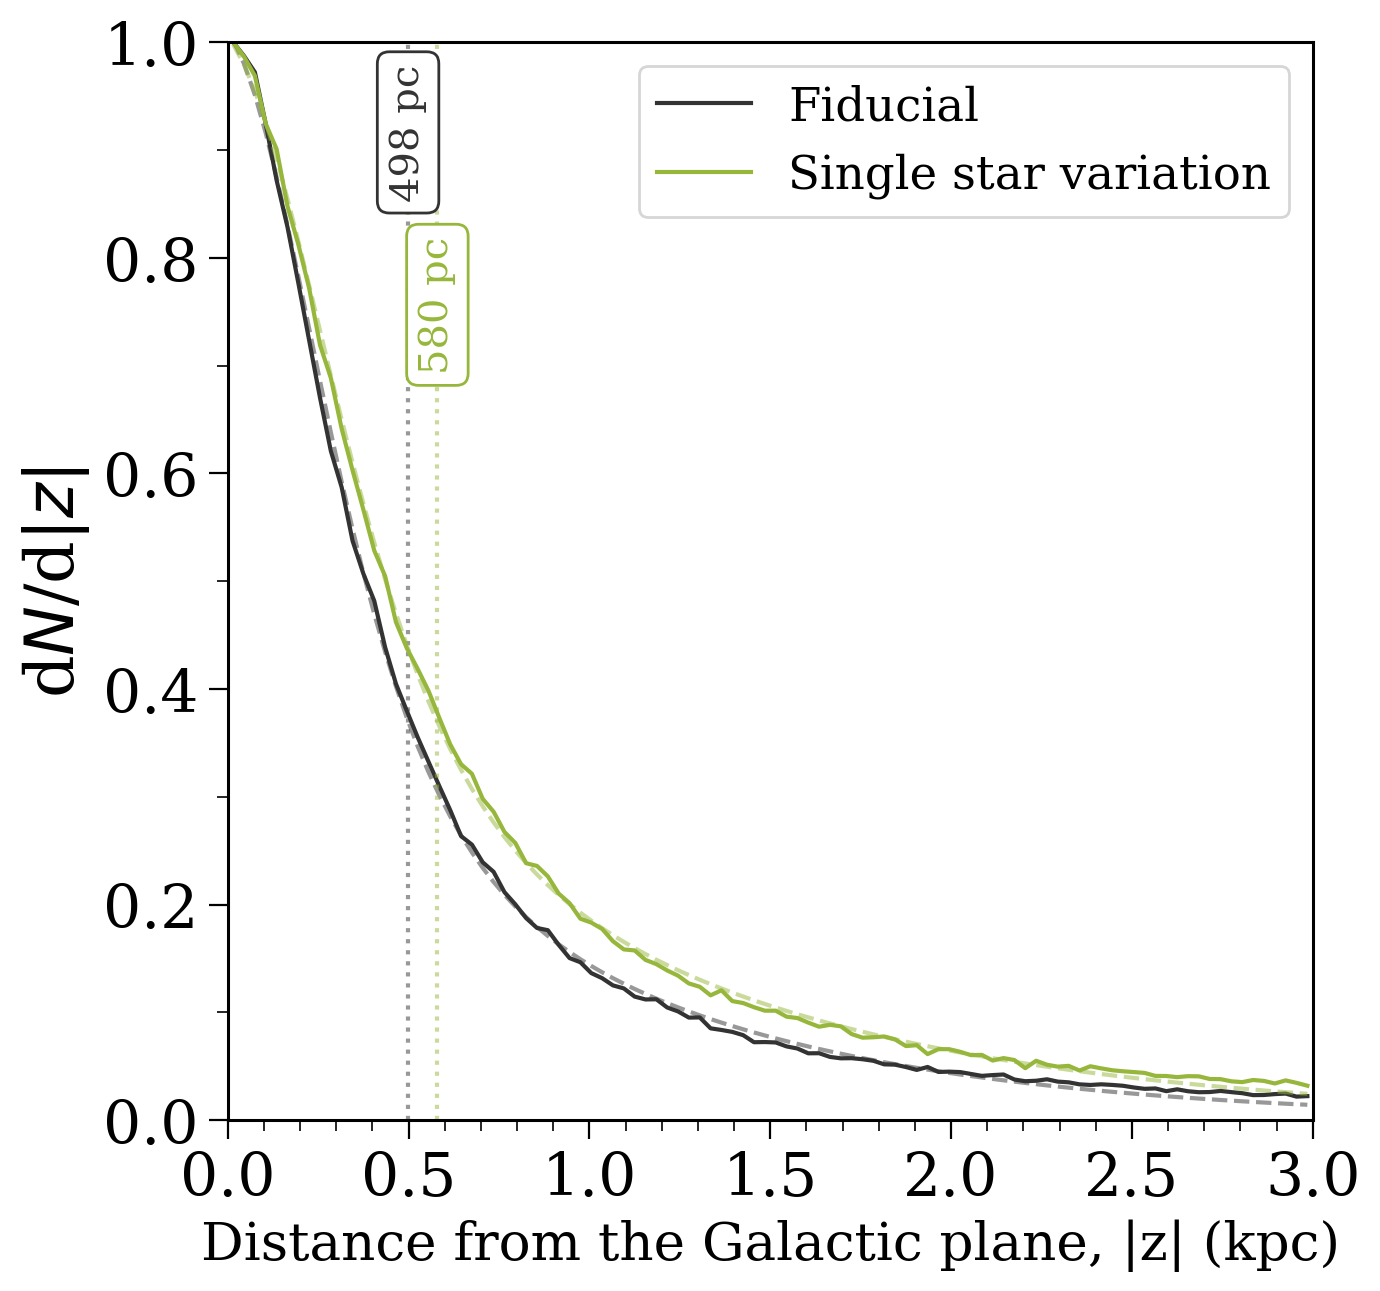

In [91]:
fig, ax = plt.subplots(figsize=(7, 7))

for z, label, colour, loc in zip(
    [kinematics["Binaries"]["pos"]["BH"][:, 2][~kinematics["Binaries"]["escaped"]["BH"]],
     kinematics["Singles"]["pos"]["BH"][:, 2][~kinematics["Singles"]["escaped"]["BH"]]],
    ["Fiducial", "Single star variation"],
    ["#333", binaries.colour],
    [0.98, 0.82]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 101),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[loc]
    )

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_singles.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Vertical position histograms

Singles 0.3714177744861552
Binaries 0.48677949540597065
Singles 0.2749643155424956
Binaries 0.38828531224670787


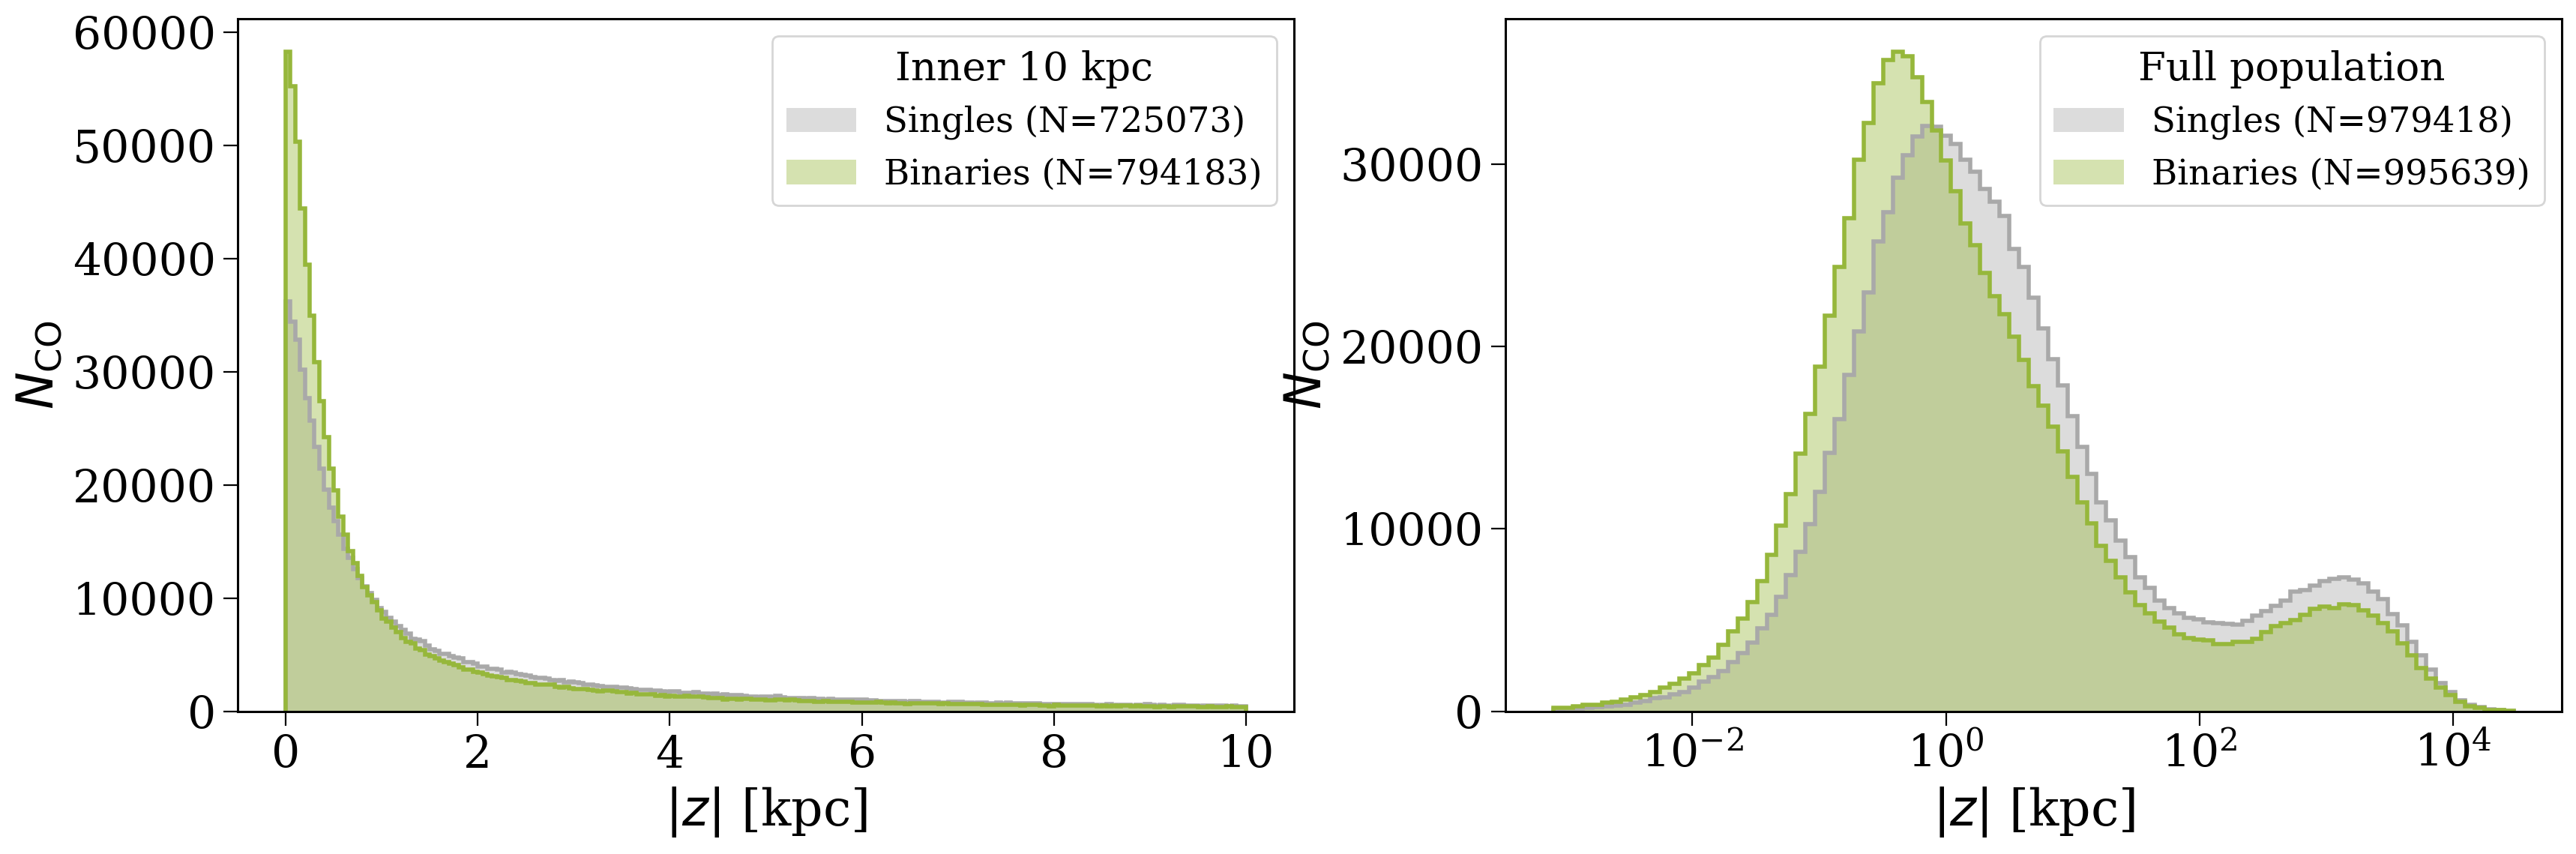

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 10, 201), np.geomspace(8e-4, 3e4, 100)]
labels = ['Inner 10 kpc', 'Full population']

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in [singles, binaries]:
        co_pos = kinematics[pop.label]["pos"]["CO"]

        mask = np.abs(co_pos[:, 2].to(u.kpc).value) < bins[-1]

        print(pop.label, (abs(co_pos[:, 2].to(u.kpc).value) < 0.5).sum() / mask.sum())

        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value), bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value), bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

## Density distributions

{'norm': <matplotlib.colors.LogNorm object at 0x150cda1c7150>}
{'norm': <matplotlib.colors.LogNorm object at 0x150cda1d6890>}


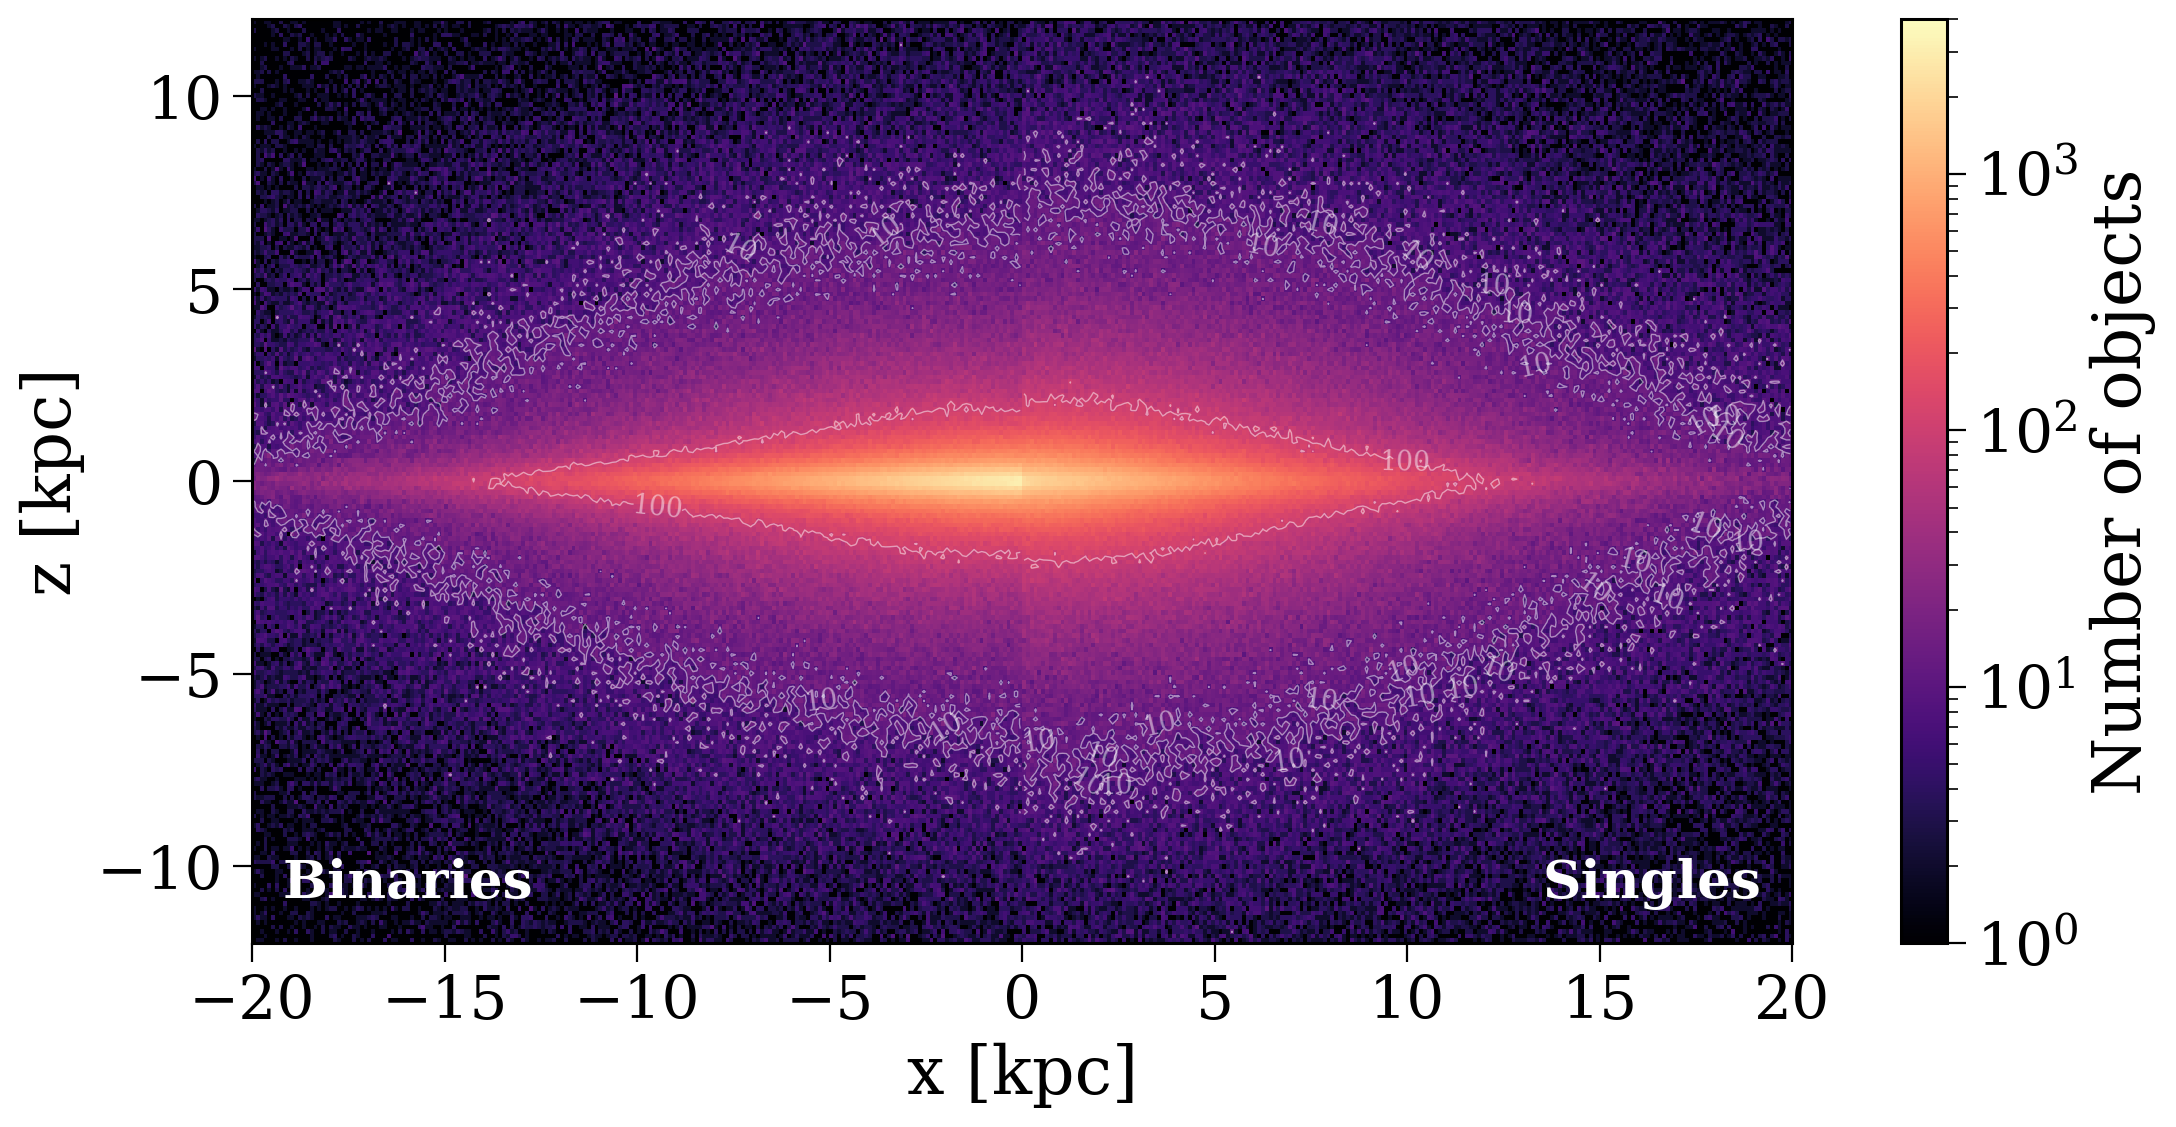

(<Figure size 1400x600 with 2 Axes>,
 <Axes: xlabel='x [kpc]', ylabel='z [kpc]'>)

In [101]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[kinematics["Singles"]["pos"]["CO"][:, 0], kinematics["Binaries"]["pos"]["CO"][:, 0]],
    zs=[kinematics["Singles"]["pos"]["CO"][:, 2], kinematics["Binaries"]["pos"]["CO"][:, 2]],
    labels=["Binaries", "Singles"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=0.25,
    contours=[10, 100],
    apply_smoothing=True,
)

## Escape fractions

In [111]:
f'Escape fraction: {kinematics["Singles"]["escaped"]["BH"].sum() / len(kinematics["Singles"]["escaped"]["BH"]):1.3f} for singles'

'Escape fraction: 0.034 for singles'

In [112]:
f'Escape fraction: {kinematics["Binaries"]["escaped"]["BH"].sum() / len(kinematics["Binaries"]["escaped"]["BH"]):1.3f} for binaries'

'Escape fraction: 0.029 for binaries'

## BH kicks

1957527
1994017


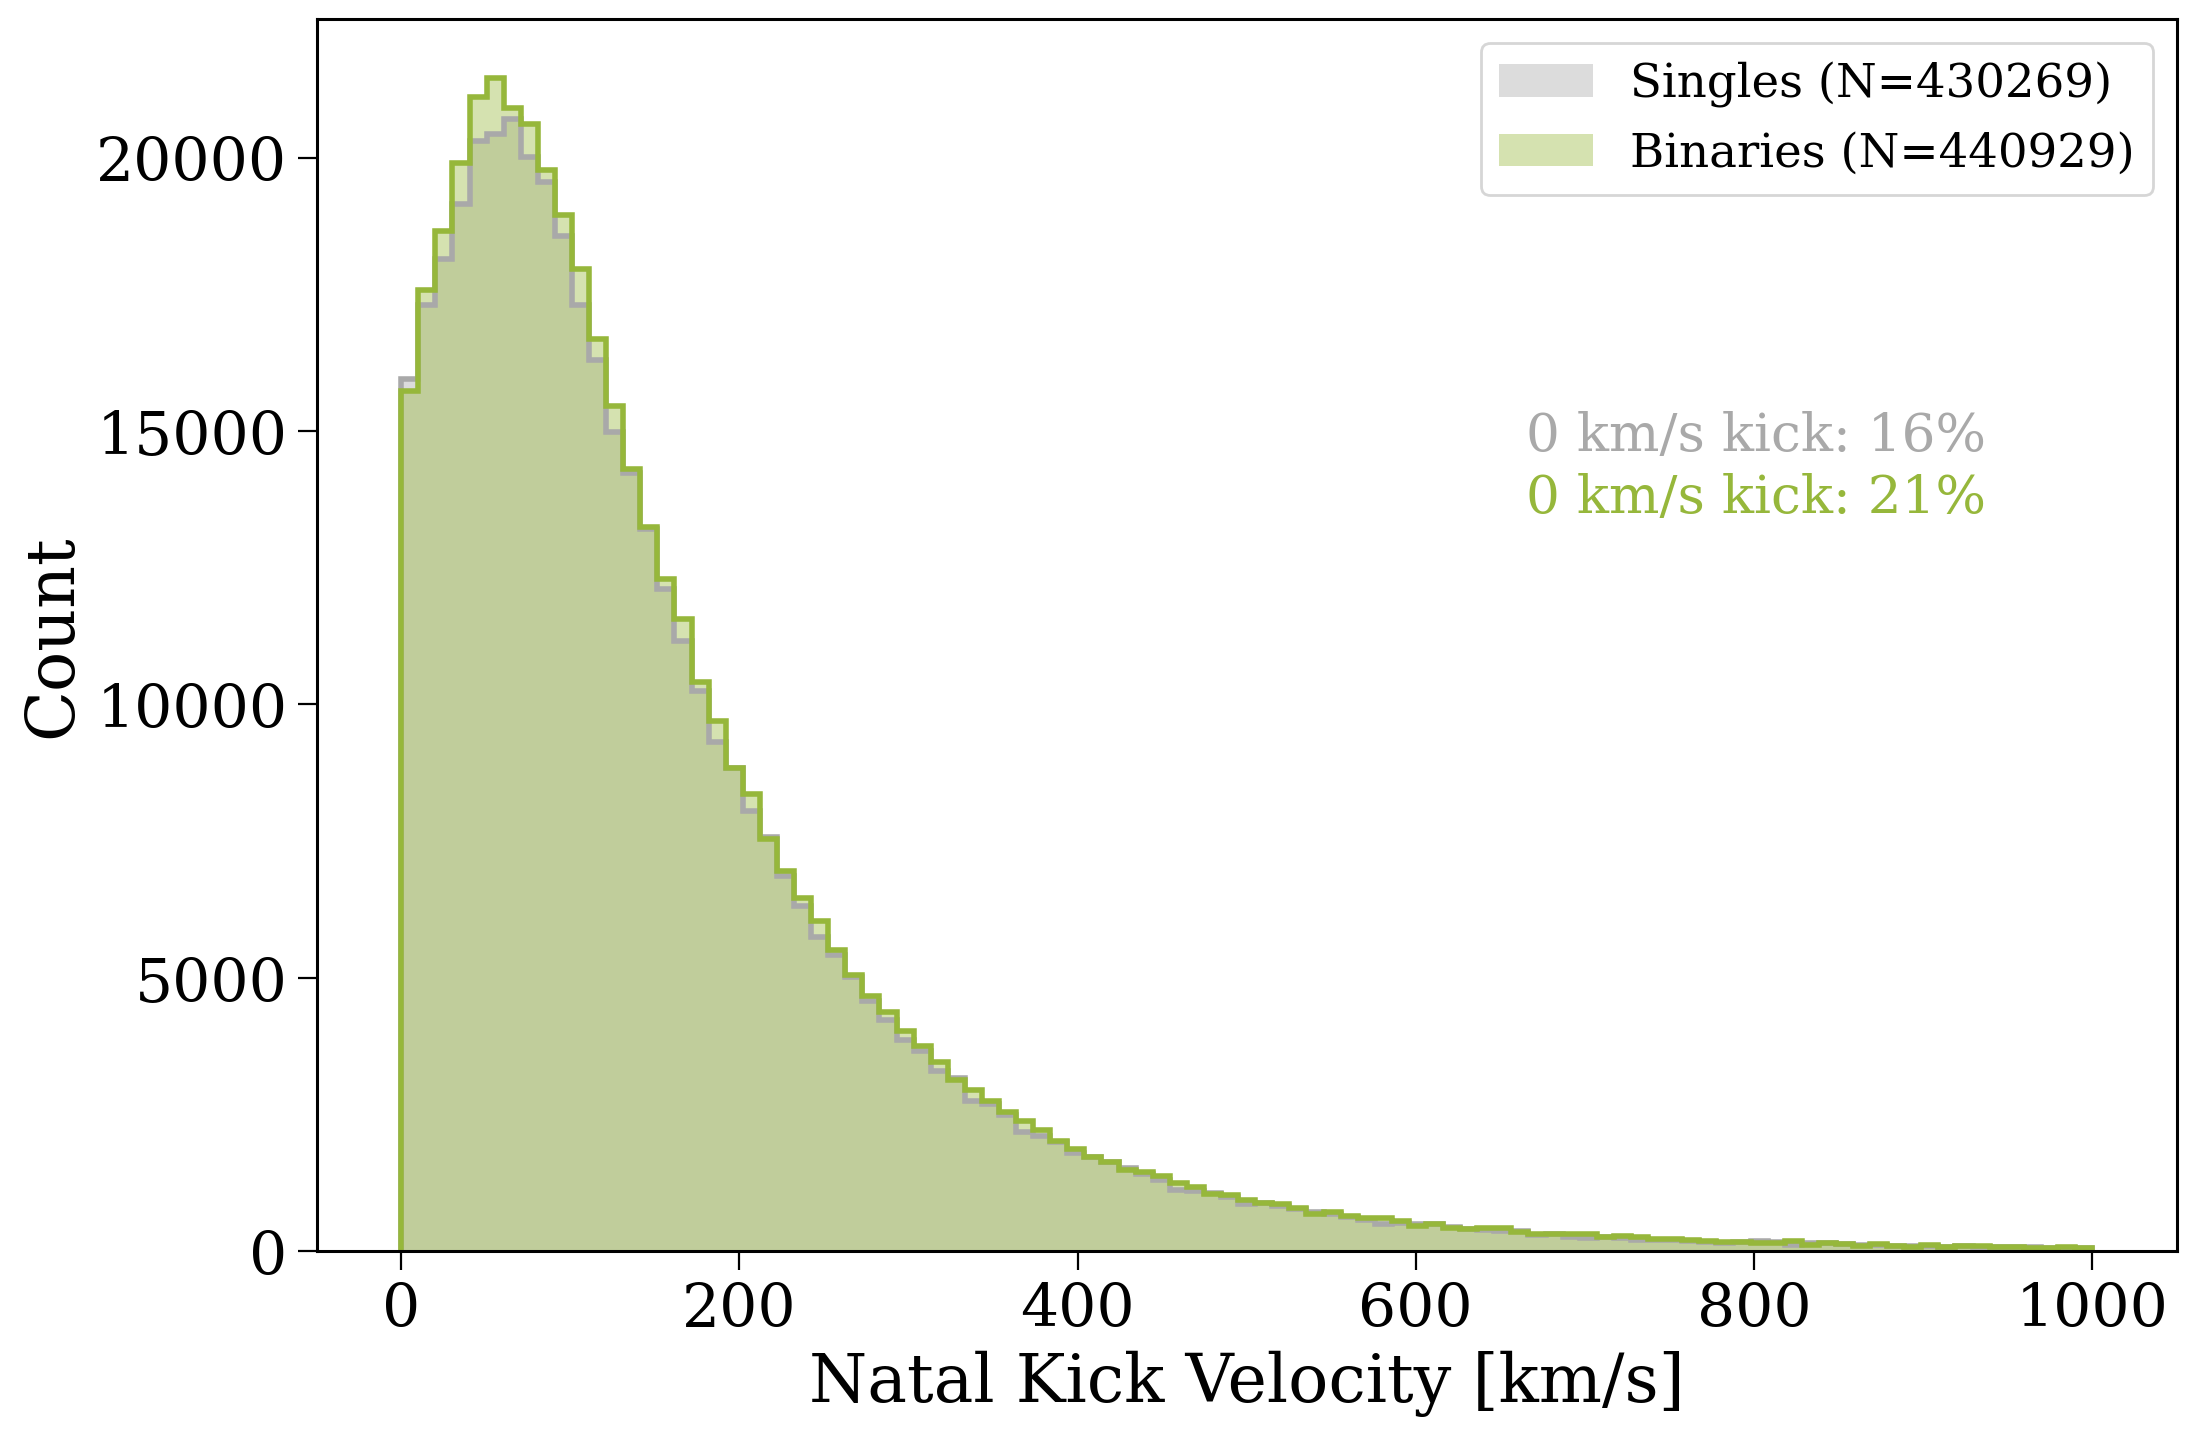

In [107]:
fig, ax = plt.subplots()

bins = np.linspace(0, 1000, 100)

for pop in [singles, binaries]:
    kick_details = pop.kick_info[pop.kick_info["star"] != 0]
    kicks = kick_details["natal_kick"]
    print(len(kicks))

    kick_rows = pop.bpp[pop.bpp["evol_type"].isin([15, 16])]
    after_kick_rows = pop.bpp[pop.bpp["row_num"].isin(kick_rows["row_num"] + 1)]
    kick_co_type = np.where(kick_details["star"] == 1, after_kick_rows["kstar_1"], after_kick_rows["kstar_2"])
    
    kicks = kicks[(np.isin(kick_co_type, [14]))]
    n_zero_kicks = (kicks == 0.0).sum()
    f_zero_kicks = n_zero_kicks / len(kicks)
    kicks = kicks[(kicks != 0.0)]

    ax.hist(kicks, bins=bins, histtype='step', lw=2, color=pop.colour)
    ax.hist(kicks, bins=bins, alpha=0.4, color=pop.colour,
            label=f"{pop.label} (N={len(kicks)})")
    
    ax.annotate(
        f"0 km/s kick: {f_zero_kicks * 100:.0f}%",
        xy=(0.65, 0.65 - 0.05 * (0 if pop.label == "Singles" else 1)),
        xycoords='axes fraction',
        color=pop.colour,
        fontsize=0.8*fs,
    )

ax.set(
    xlabel="Natal Kick Velocity [km/s]",
    ylabel="Count",
)
ax.legend()
plt.show()

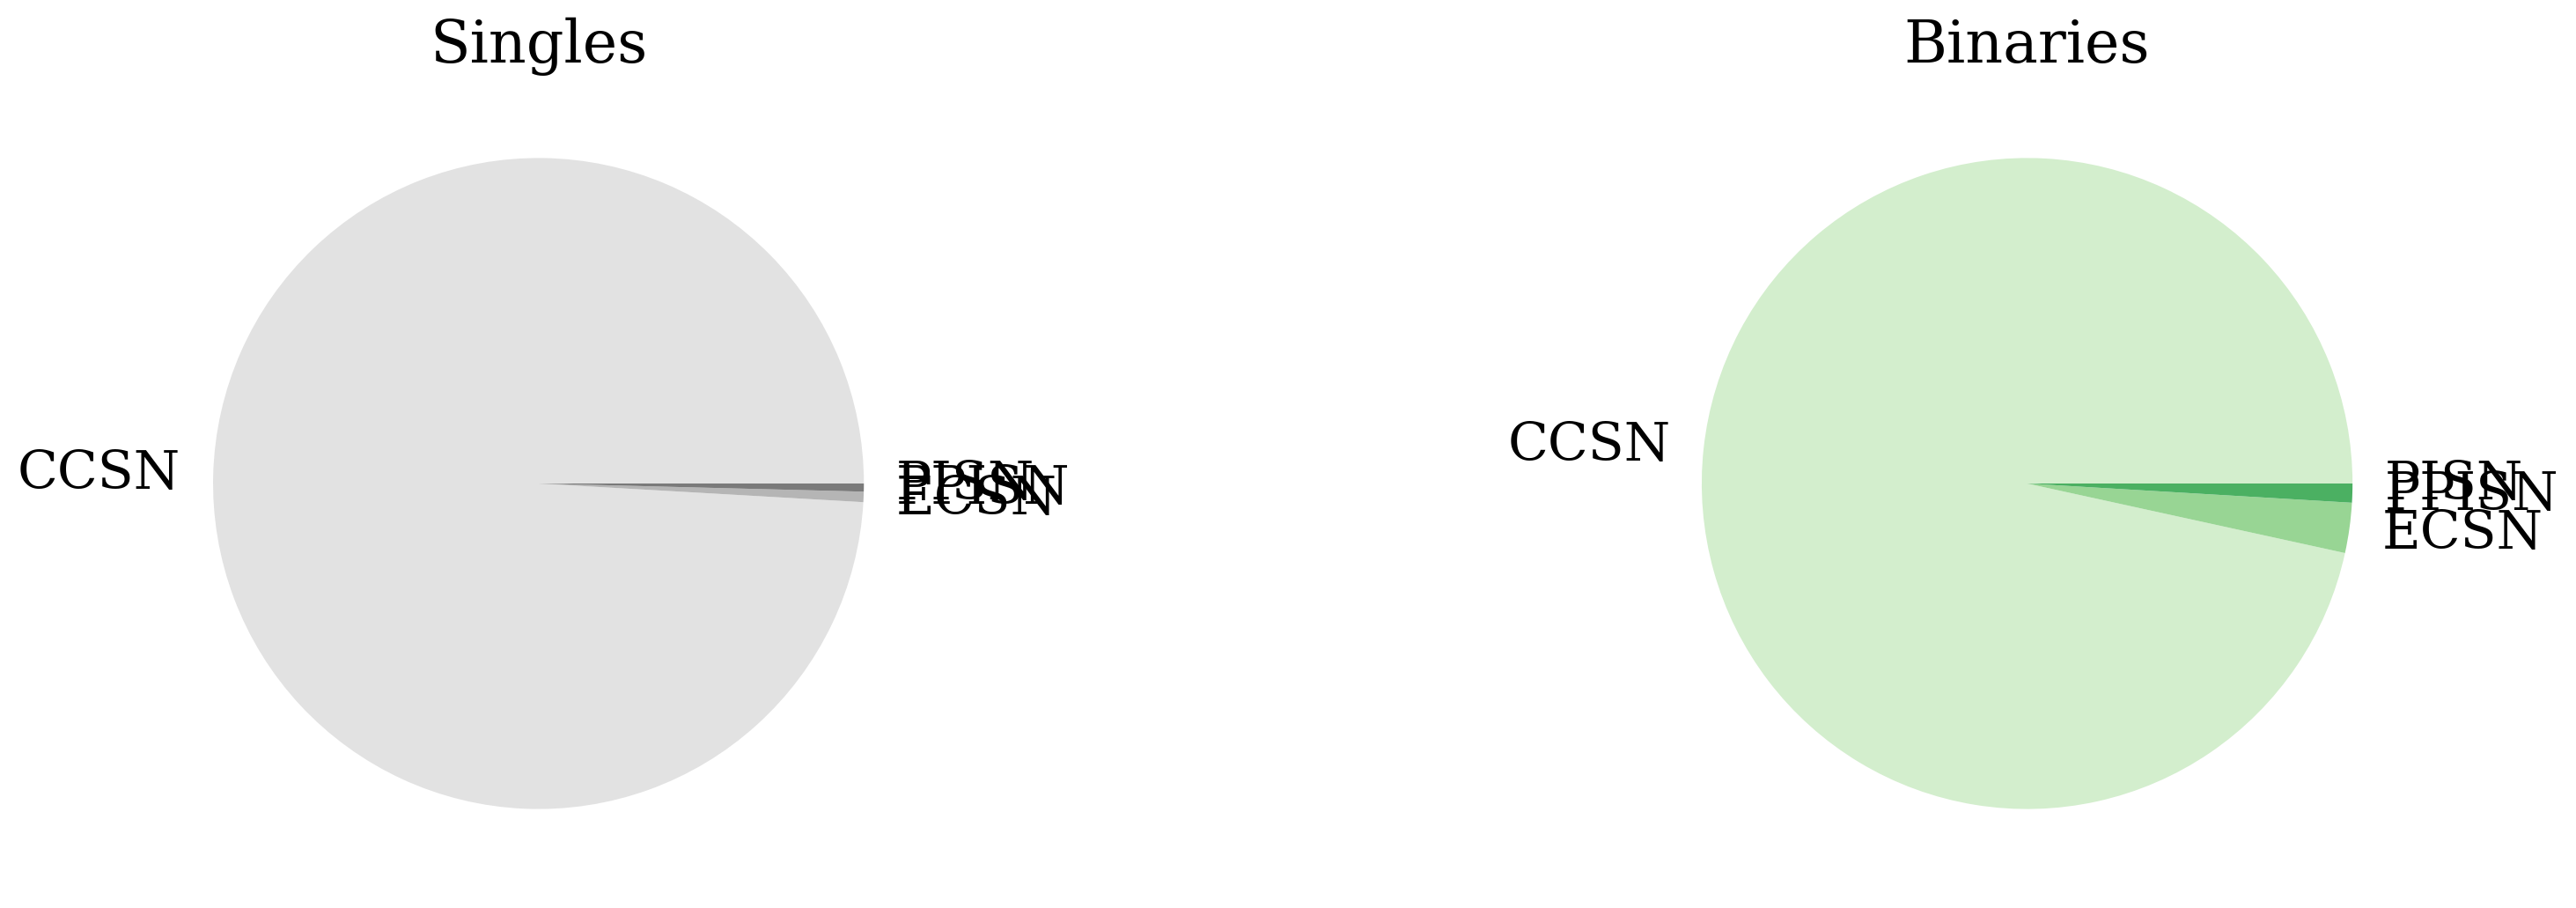

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for pop, ax in zip([singles, binaries], axes):
    sn_types = np.concatenate((
        pop.final_bpp["SN_1"],
        pop.final_bpp["SN_2"],
    ))
    types, counts = np.unique(sn_types[sn_types > 0], return_counts=True)

    type_label_dict = {
        1: "CCSN",
        2: "ECSN",
        3: "USSN",
        4: "AIC",
        5: "MIC",
        6: "PPISN",
        7: "PISN",
    }

    ax.pie(
        counts,
        labels=[type_label_dict[t] for t in types],
        colors=sns.color_palette("Greens" if pop.label == 'Binaries' else "Greys", n_colors=len(types)),
    )

    ax.set_title(pop.label, fontsize=fs)

# Initial conditions

## Mass

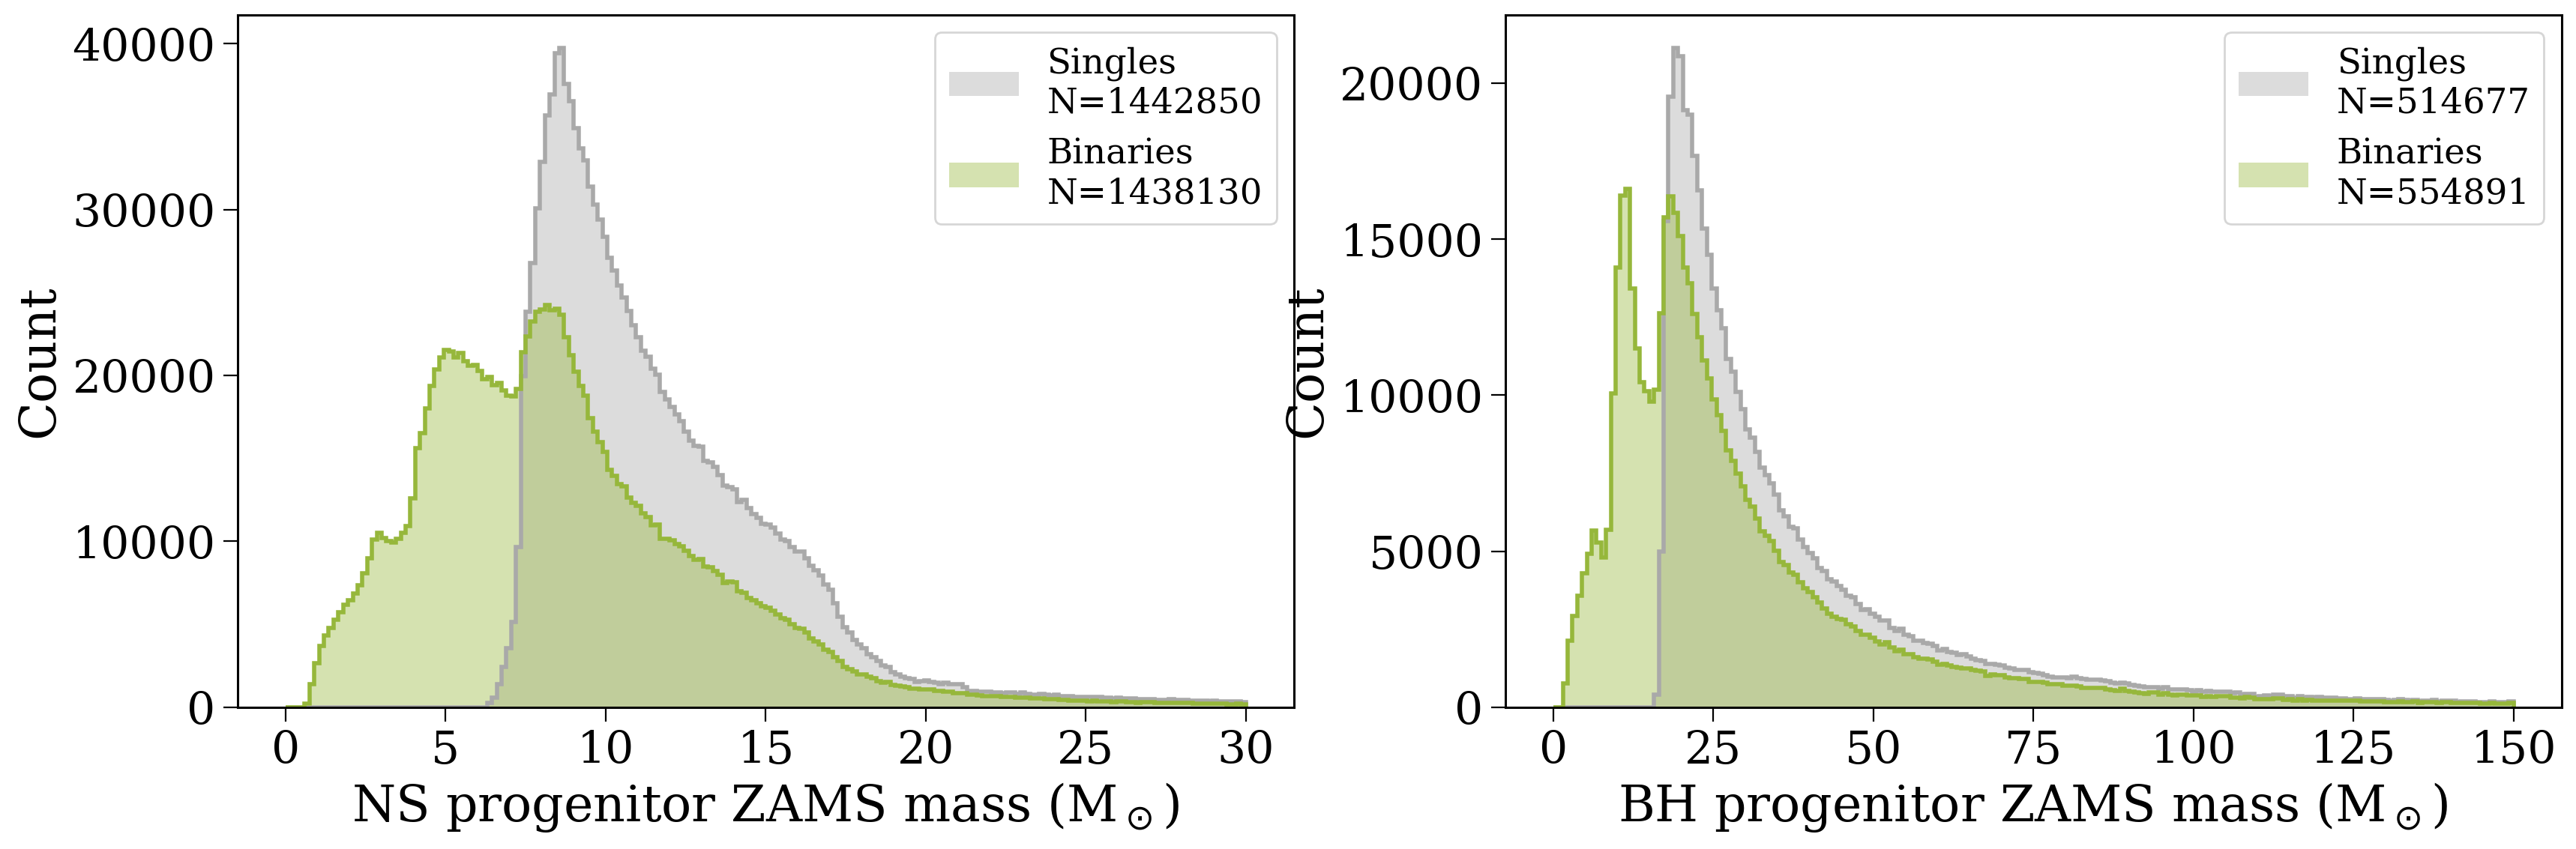

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    plotting.compare_table_quantity(
        pops=[singles, binaries],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor ZAMS mass (M$_\odot$)",
        ylabel="Count",
        density=False,
        ax=ax,
        fig=fig,
        show=False
    )
plt.show()

## Metallicity

Worrying spike up at $Z = 0.03$

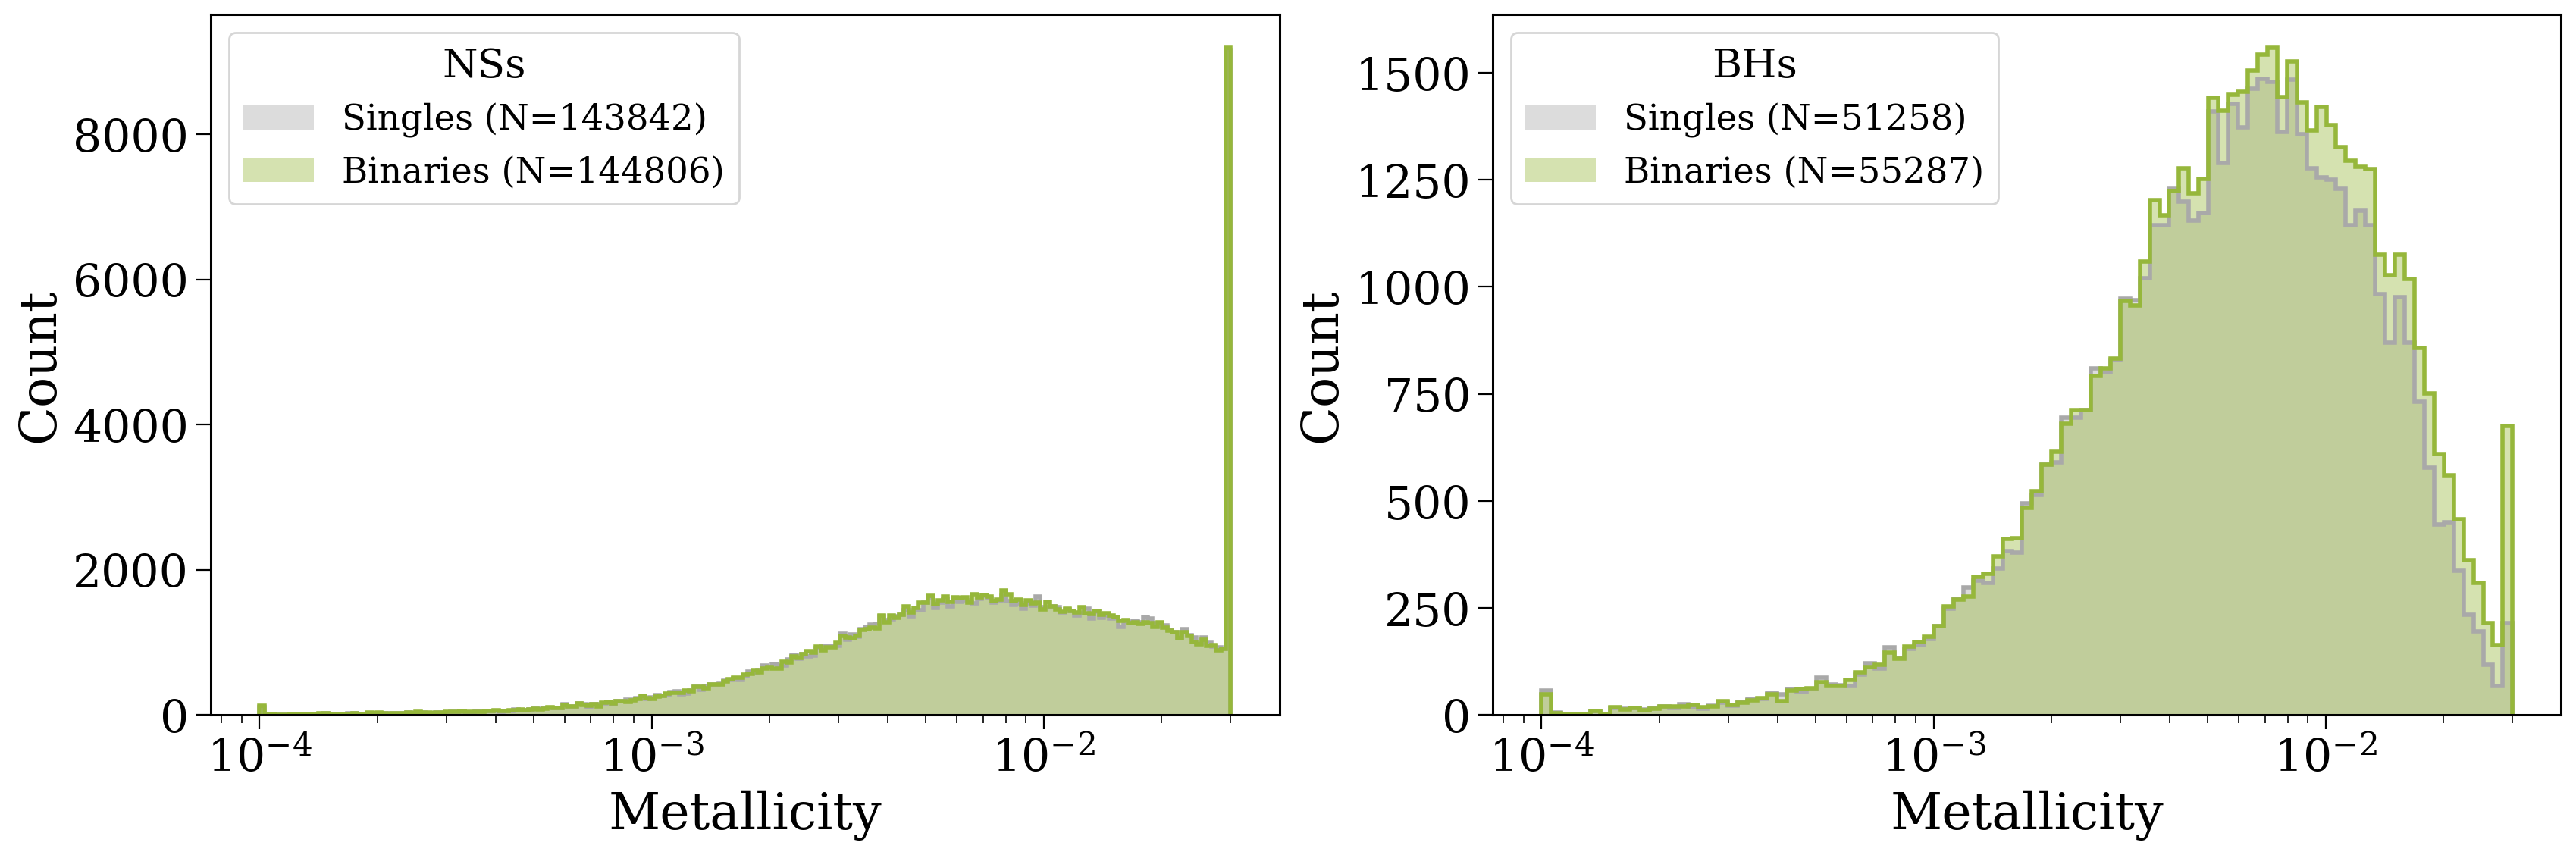

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.geomspace(1e-4, 0.03, 200), np.geomspace(1e-4, 0.03, 100)]):
    for pop in [singles, binaries]:
        init_Z = np.concatenate((
            pop.initC["metallicity"][pop.final_bpp["kstar_1"] == kstar],
            pop.initC["metallicity"][pop.final_bpp["kstar_2"] == kstar]
        ))

        ax.hist(init_Z, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(init_Z, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(init_Z)})")

    ax.set(
        xlabel=f"Metallicity",
        ylabel="Count",
        xscale='log'
    )
    ax.legend(title=f"{co_type}s")
plt.show()

## Delay time

Reproduces Wagg+25

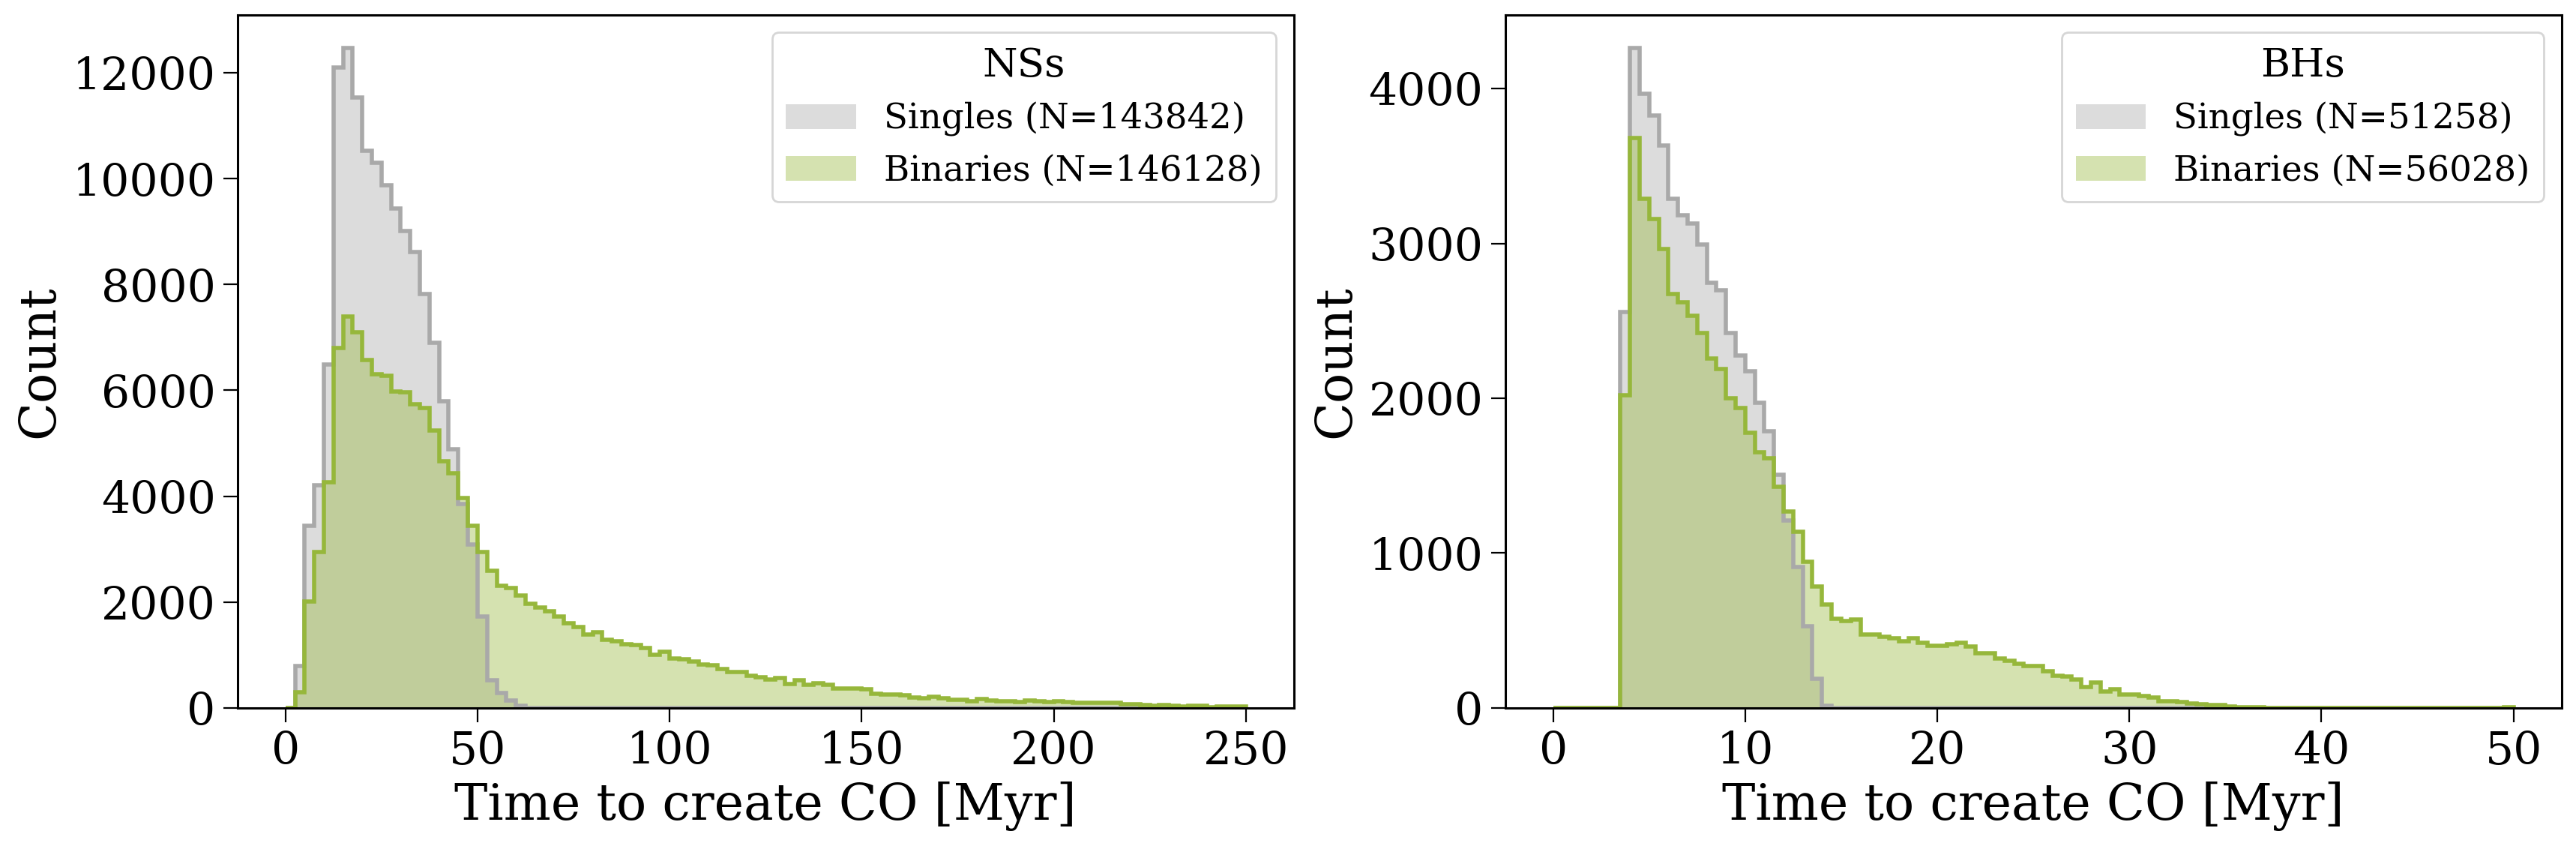

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 250, 101), np.linspace(0, 50, 101)]):
    for pop in [singles, binaries]:
        co_form_time = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
        ))

        ax.hist(co_form_time, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(co_form_time, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(co_form_time)})")

    ax.set(
        xlabel=f"Time to create CO [Myr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()